In [7]:
# Cell 1: Setup
import os
import sys
sys.path.append('../src')
import torch
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.11.0+cpu


In [8]:
# Cell 2: Load data
from training.data_loader import get_data_loaders

BATCH_SIZE = 32
train_loader, val_loader, test_loader = get_data_loaders(batch_size=BATCH_SIZE)


Loaded 8830 segments from ../data/train_test_split/train.npy
Shape: (8830, 128, 49), Memory: 211.3 MB
Loaded 3204 segments from ../data/train_test_split/val.npy
Shape: (3204, 128, 49), Memory: 76.7 MB
Loaded 3961 segments from ../data/train_test_split/test.npy
Shape: (3961, 128, 49), Memory: 94.8 MB

Train batches: 276, Val batches: 101, Test batches: 124


In [9]:
# Check shape of saved segments
import numpy as np
segments = np.load('../data/processed/maestro_segments.npy')
print(f"Segment shape: {segments.shape[1:]}")  # Should be (64, 49) or (128, 49)

Segment shape: (128, 49)


In [8]:
# Cell 3: Create model
from models.autoencoder import LSTMAutoencoder

model = LSTMAutoencoder(
    input_dim=49,
    hidden_dim=128,
    latent_dim=8,
    seq_len=64,
    num_layers=2
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 815,289


In [ ]:
# Cell 4: Verify Trainer Configuration
import sys
sys.path.append('../src')
import torch
from models.autoencoder import LSTMAutoencoder
from training.train_ae import AETrainer
from training.data_loader import get_data_loaders

print("="*50)
print("TRAINER CONFIGURATION VERIFICATION")
print("="*50)

# 1. Check model configuration
print("\n1. MODEL CONFIGURATION:")
model = LSTMAutoencoder(
    input_dim=49,
    hidden_dim=128,
    latent_dim=8,
    seq_len=128,
    num_layers=2
)
total_params = sum(p.numel() for p in model.parameters())
print(f"   Hidden dim: 128")
print(f"   Latent dim: 16")
print(f"   Num layers: 2")
print(f"   Total parameters: {total_params:,}")

# 2. Check trainer initialization
print("\n2. TRAINER INITIALIZATION:")
trainer = AETrainer(model, device='cpu', learning_rate=0.001)
print(f"   Device: {trainer.device}")
print(f"   Criterion: {trainer.criterion.__class__.__name__}")
print(f"   Optimizer: {trainer.optimizer.__class__.__name__}")
print(f"   Learning rate: {trainer.optimizer.param_groups[0]['lr']}")
print(f"   Scheduler: {trainer.scheduler.__class__.__name__}")
print(f"   Scheduler mode: {trainer.scheduler.mode}")
print(f"   Scheduler patience: {trainer.scheduler.patience}")
print(f"   Scheduler factor: {trainer.scheduler.factor}")

# 3. Check data loaders
print("\n3. DATA LOADERS:")
train_loader, val_loader, test_loader = get_data_loaders(batch_size=32)
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

# 4. Verify a sample batch
print("\n4. SAMPLE BATCH VERIFICATION:")
for batch in train_loader:
    print(f"   Batch shape: {batch.shape}")
    print(f"   Batch dtype: {batch.dtype}")
    print(f"   Batch min: {batch.min():.4f}")
    print(f"   Batch max: {batch.max():.4f}")
    print(f"   Batch mean: {batch.mean():.4f}")
    break

# 5. Test forward pass
print("\n5. FORWARD PASS TEST:")
with torch.no_grad():
    test_batch = next(iter(train_loader))
    recon, z = model(test_batch)
    print(f"   Input shape: {test_batch.shape}")
    print(f"   Latent shape: {z.shape}")
    print(f"   Recon shape: {recon.shape}")
    print(f"   Recon min: {recon.min():.4f}")
    print(f"   Recon max: {recon.max():.4f}")
    print(f"   Recon mean: {recon.mean():.4f}")

print("\n" + "="*50)
print("VERIFICATION COMPLETE")
print("="*50)
print("\nProceed to training if all checks passed.")

TRAINER CONFIGURATION VERIFICATION

1. MODEL CONFIGURATION:
   Hidden dim: 128
   Latent dim: 16
   Num layers: 2
   Total parameters: 815,289

2. TRAINER INITIALIZATION:
   Device: cpu
   Criterion: MSELoss
   Optimizer: Adam
   Learning rate: 0.001
   Scheduler: ReduceLROnPlateau
   Scheduler mode: min
   Scheduler patience: 5
   Scheduler factor: 0.5

3. DATA LOADERS:
Loaded 8830 segments from ../data/train_test_split/train.npy
Shape: (8830, 128, 49), Memory: 211.3 MB
Loaded 3204 segments from ../data/train_test_split/val.npy
Shape: (3204, 128, 49), Memory: 76.7 MB
Loaded 3961 segments from ../data/train_test_split/test.npy
Shape: (3961, 128, 49), Memory: 94.8 MB

Train batches: 276, Val batches: 101, Test batches: 124
   Train batches: 276
   Val batches: 101
   Test batches: 124

4. SAMPLE BATCH VERIFICATION:
   Batch shape: torch.Size([32, 1, 128, 49])
   Batch dtype: torch.float32
   Batch min: 0.0000
   Batch max: 0.8898
   Batch mean: 0.0833

5. FORWARD PASS TEST:
   Input sha

In [ ]:
# Cell 5: Train
#from training.train_ae import AETrainer

#trainer = AETrainer(model, device='cpu', learning_rate=0.001)
train_losses, val_losses = trainer.train(
    train_loader, val_loader,
    epochs=120,
    save_path='../outputs/models/autoencoder_maestro.pth'
)


Training LSTM Autoencoder on MAESTRO
Device: cpu
Epochs: 120
Learning rate: 0.001



Epoch 1/120 - Train Loss: 0.043135, Val Loss: 0.033305, LR: 0.001000
  -> Saved best model


Epoch 2/120 - Train Loss: 0.035366, Val Loss: 0.033333, LR: 0.001000


Epoch 3/120 - Train Loss: 0.035374, Val Loss: 0.033313, LR: 0.001000


Epoch 4/120 - Train Loss: 0.035375, Val Loss: 0.033321, LR: 0.001000


...

Epoch 116/120 - Train Loss: 0.025743, Val Loss: 0.026759, LR: 0.000063


Epoch 117/120 - Train Loss: 0.025736, Val Loss: 0.026768, LR: 0.000063


Epoch 118/120 - Train Loss: 0.025735, Val Loss: 0.026761, LR: 0.000063


Epoch 119/120 - Train Loss: 0.025734, Val Loss: 0.026769, LR: 0.000063


Epoch 120/120 - Train Loss: 0.025730, Val Loss: 0.026760, LR: 0.000031

Best Validation Loss: 0.026754


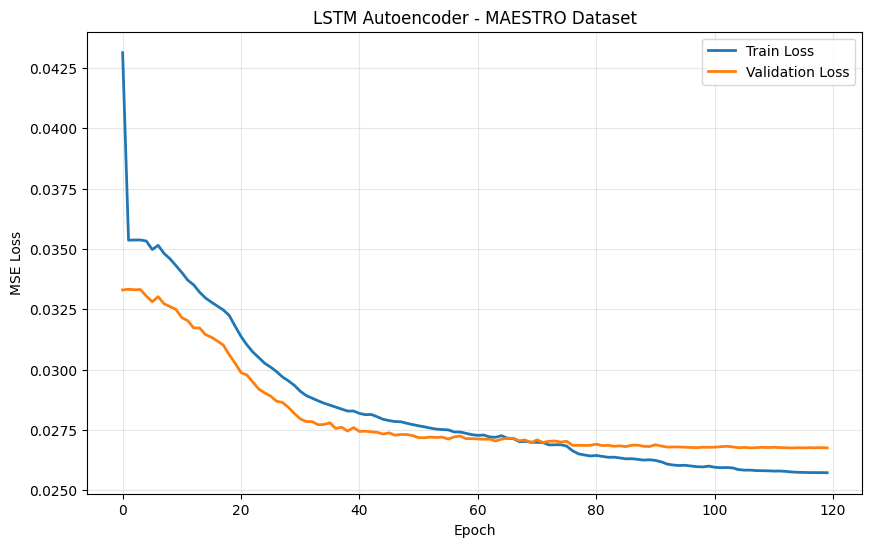

In [ ]:
# Cell 6: Plot loss curve
trainer.plot_losses()

In [5]:
# Cell 6: Test evaluation
test_loss = trainer.validate(test_loader)
print(f"Test Loss: {test_loss:.6f}")

Test Loss: 0.026636


Loaded 8830 segments from ../data/train_test_split/train.npy
Shape: (8830, 128, 49), Memory: 211.3 MB
Loaded 3204 segments from ../data/train_test_split/val.npy
Shape: (3204, 128, 49), Memory: 76.7 MB
Loaded 3961 segments from ../data/train_test_split/test.npy
Shape: (3961, 128, 49), Memory: 94.8 MB

Train batches: 8830, Val batches: 3204, Test batches: 3961
Real segment - min: 0.0000, max: 0.7953, mean: 0.0565
Reconstructed - min: 0.0001, max: 0.4763, mean: 0.0501


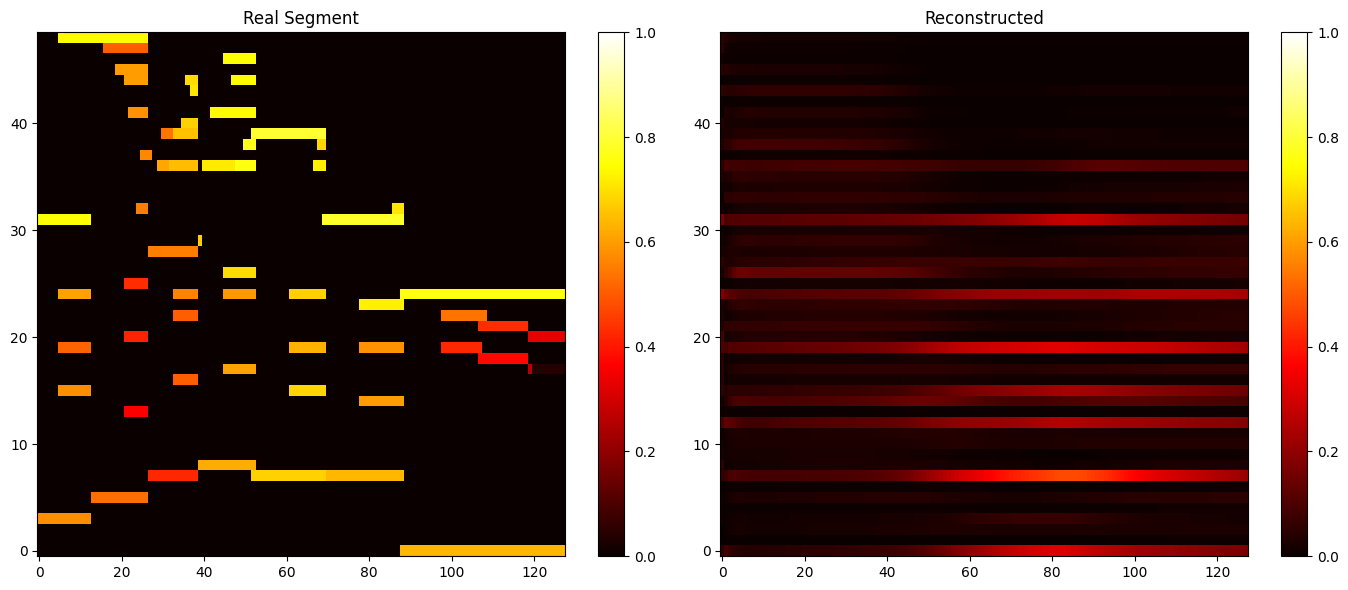


Reconstruction value distribution:
  Values below 0.1: 85.4%
  Values above 0.9: 0.0%
  Values between 0.4-0.6: 0.4%


In [ ]:
# Cell 7: Visualize Real vs Reconstructed
import matplotlib.pyplot as plt
import torch
from training.data_loader import get_data_loaders

# Load test data
_, _, test_loader = get_data_loaders(batch_size=1)

# Get one real segment
for batch in test_loader:
    real_segment = batch
    break

# Load best model
checkpoint = torch.load('../outputs/models/autoencoder_maestro.pth', map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Reconstruct
with torch.no_grad():
    recon, _ = model(real_segment)
    recon = recon.squeeze().cpu().numpy()
    real = real_segment.squeeze().cpu().numpy()

print(f"Real segment - min: {real.min():.4f}, max: {real.max():.4f}, mean: {real.mean():.4f}")
print(f"Reconstructed - min: {recon.min():.4f}, max: {recon.max():.4f}, mean: {recon.mean():.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im1 = axes[0].imshow(real.T, aspect='auto', origin='lower', cmap='hot', vmin=0, vmax=1)
axes[0].set_title('Real Segment')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(recon.T, aspect='auto', origin='lower', cmap='hot', vmin=0, vmax=1)
axes[1].set_title('Reconstructed')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.savefig('../outputs/plots/real_vs_reconstructed_final.png', dpi=150)
plt.show()

# Also check variation in reconstruction
print(f"\nReconstruction value distribution:")
print(f"  Values below 0.1: {(recon < 0.1).sum() / recon.size * 100:.1f}%")
print(f"  Values above 0.9: {(recon > 0.9).sum() / recon.size * 100:.1f}%")
print(f"  Values between 0.4-0.6: {((recon > 0.4) & (recon < 0.6)).sum() / recon.size * 100:.1f}%")

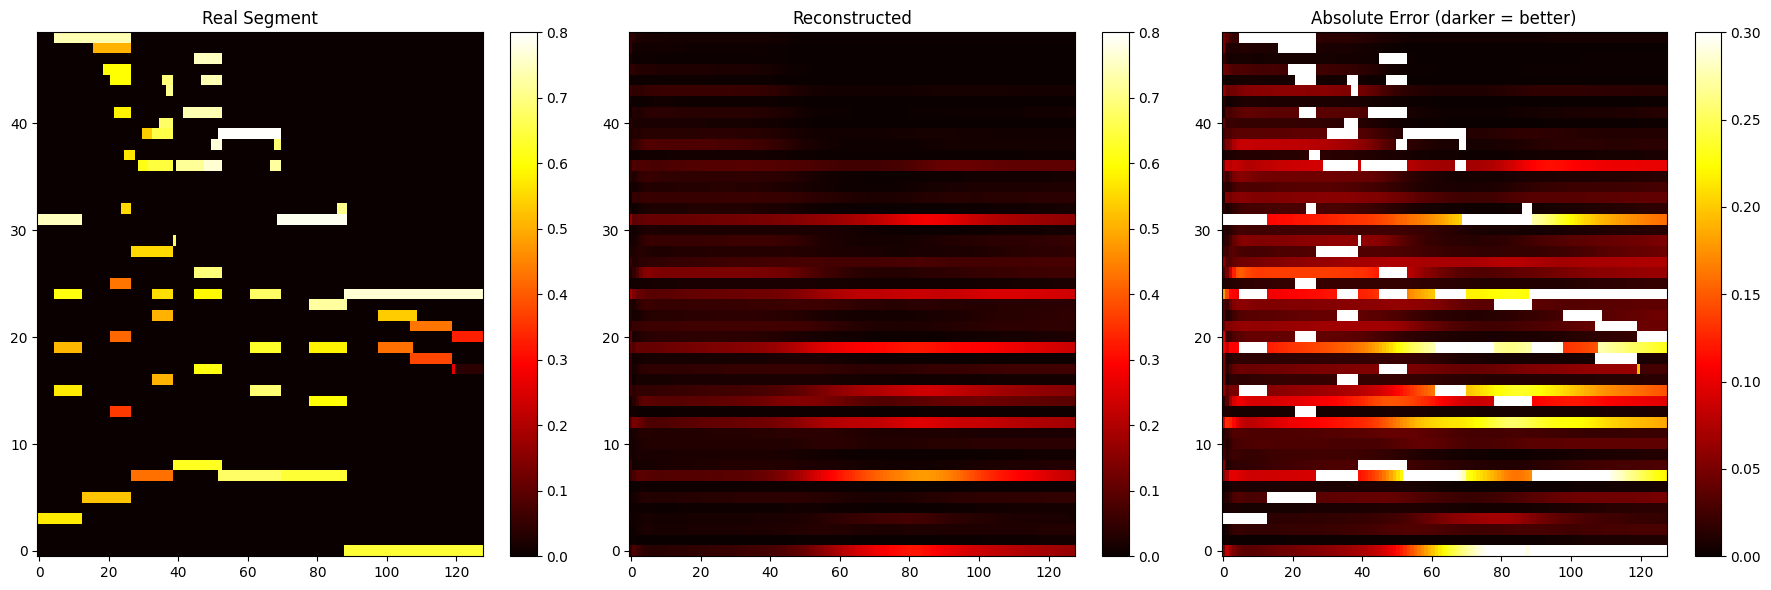

Mean absolute error: 0.0850
Max absolute error: 0.7848


: 

In [ ]:
# Cell 8: Enhanced visualization with difference map
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Real
im1 = axes[0].imshow(real.T, aspect='auto', origin='lower', cmap='hot', vmin=0, vmax=0.8)
axes[0].set_title('Real Segment')
plt.colorbar(im1, ax=axes[0])

# Reconstructed
im2 = axes[1].imshow(recon.T, aspect='auto', origin='lower', cmap='hot', vmin=0, vmax=0.8)
axes[1].set_title('Reconstructed')
plt.colorbar(im2, ax=axes[1])

# Difference (absolute error)
diff = np.abs(real - recon)
im3 = axes[2].imshow(diff.T, aspect='auto', origin='lower', cmap='hot', vmin=0, vmax=0.3)
axes[2].set_title('Absolute Error (darker = better)')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.savefig('../outputs/plots/real_vs_recon_diff.png', dpi=150)
plt.show()

print(f"Mean absolute error: {diff.mean():.4f}")
print(f"Max absolute error: {diff.max():.4f}")

In [ ]:
# Cell 9: Generate samples with correct latent dimension
import torch
import os
from generation.midi_export import numpy_to_midi

# Check what latent dimension the saved model expects
checkpoint = torch.load('../outputs/models/autoencoder_maestro.pth', map_location='cpu')
print(f"Model saved from epoch {checkpoint['epoch']}")

# Inspect the decoder's first layer shape
decoder_fc_hidden = checkpoint['model_state_dict']['decoder.fc_hidden.weight']
latent_dim = decoder_fc_hidden.shape[1]
print(f"Latent dimension from saved model: {latent_dim}")

# Reload model with correct dimension
from models.autoencoder import LSTMAutoencoder

model = LSTMAutoencoder(
    input_dim=49,
    hidden_dim=128,
    latent_dim=latent_dim,  # Use the dimension from saved model
    seq_len=128,
    num_layers=2
)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Model loaded successfully with latent_dim={latent_dim}")

# Generate samples
output_dir = '../outputs/generated_midis/task1_maestro_final/'
os.makedirs(output_dir, exist_ok=True)

for i in range(5):
    with torch.no_grad():
        z = torch.randn(1, latent_dim)
        generated = model.decoder(z)
        generated = generated.squeeze().cpu().numpy()
    
    output_path = os.path.join(output_dir, f'task1_sample_{i+1}.mid')
    numpy_to_midi(generated, output_path, tempo=120, velocity_scale=100)
    
    active_notes = (generated > 0.05).sum()
    print(f"Sample {i+1}: mean={generated.mean():.4f}, max={generated.max():.4f}, active_notes={active_notes}")

print(f"\n5 samples saved to {output_dir}")

Model saved from epoch 114
Latent dimension from saved model: 8
Model loaded successfully with latent_dim=8
MIDI saved: ../outputs/generated_midis/task1_maestro_final/task1_sample_1.mid
Sample 1: mean=0.0824, max=0.7945, active_notes=2854
MIDI saved: ../outputs/generated_midis/task1_maestro_final/task1_sample_2.mid
Sample 2: mean=0.0811, max=0.5308, active_notes=3041
MIDI saved: ../outputs/generated_midis/task1_maestro_final/task1_sample_3.mid
Sample 3: mean=0.0913, max=0.5696, active_notes=2969
MIDI saved: ../outputs/generated_midis/task1_maestro_final/task1_sample_4.mid
Sample 4: mean=0.0674, max=0.4985, active_notes=2597
MIDI saved: ../outputs/generated_midis/task1_maestro_final/task1_sample_5.mid
Sample 5: mean=0.0736, max=0.7631, active_notes=2473

5 samples saved to ../outputs/generated_midis/task1_maestro_final/


Loaded sample 1: shape (128, 49)
Loaded sample 2: shape (128, 49)
Loaded sample 3: shape (128, 49)
Loaded sample 4: shape (128, 49)
Loaded sample 5: shape (128, 49)

Loaded 5 generated samples

EVALUATION METRICS - Task 1: LSTM Autoencoder
Rhythm Diversity: 0.5210 (+- 0.1344)
Repetition Ratio: 0.1000 (+- 0.1159)
Pitch Histogram Similarity: 0.9848 (+- 0.3634)
Loaded human feedback from ../data/human_feedback/Task_1/feedback.xlsx
  Participants: 10
  Samples: 5
  Score range: 0.5 - 1.4

HUMAN LISTENING SCORE - Task 1: LSTM Autoencoder
Participants: 10
Samples evaluated: 5
Overall Score: 0.97 / 5.00 (+- 0.19)
Score Range: 0.5 - 1.4

Per-Sample Scores:
  Sample 1: 0.94
  Sample 2: 0.97
  Sample 3: 0.95
  Sample 4: 0.92
  Sample 5: 1.05


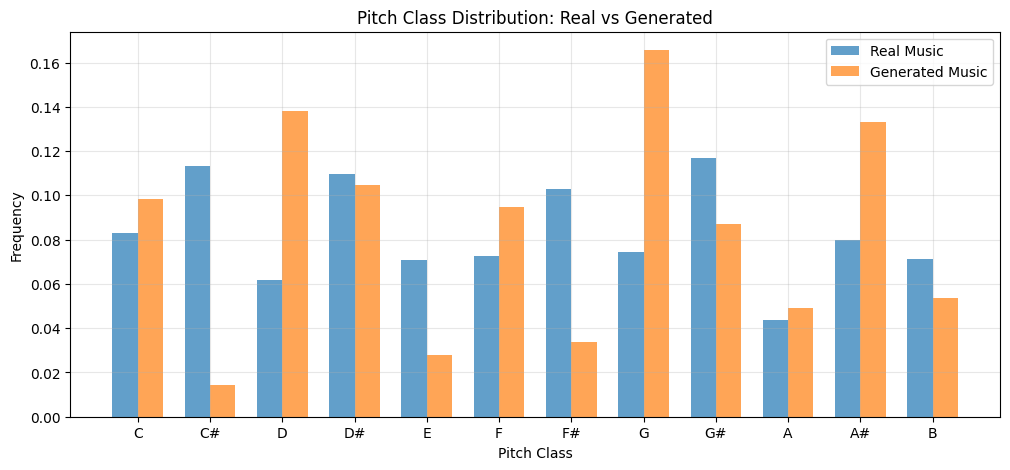

Pitch Histogram Similarity: 0.9848
Plot saved to ../outputs/plots/task1_pitch_histogram_comparison.png


: 

In [ ]:
# Cell 10: Evaluate Task 1 Model Metrics
import sys
sys.path.append('../src')
import numpy as np
import os
import pretty_midi
import matplotlib.pyplot as plt
from evaluation.pitch_histogram import compute_pitch_histogram
from evaluation.metrics import compute_all_metrics, print_metrics
from evaluation.human_score import load_human_scores, compute_human_score, print_human_score

def midi_to_piano_roll_for_metrics(midi_path, fs=8, min_pitch=36, max_pitch=84):
    """Convert MIDI file to piano roll for metric calculation"""
    pm = pretty_midi.PrettyMIDI(midi_path)
    
    if len(pm.instruments) == 0:
        return None
    
    # Take first instrument
    piano_roll = pm.get_piano_roll(fs=fs)
    
    # Trim to pitch range
    piano_roll = piano_roll[min_pitch:max_pitch+1]
    
    # Normalize to [0, 1]
    if piano_roll.max() > 0:
        piano_roll = piano_roll / piano_roll.max()
    
    # Transpose to (time, pitches)
    piano_roll = piano_roll.T
    
    return piano_roll.astype(np.float32)

# Load generated samples from .mid files
generated_dir = '../outputs/generated_midis/task1_autoencoder/'
generated_samples = []

for i in range(1, 6):  # You have 5 files
    midi_path = os.path.join(generated_dir, f'task1_sample_{i}.mid')
    if os.path.exists(midi_path):
        piano_roll = midi_to_piano_roll_for_metrics(midi_path)
        if piano_roll is not None:
            generated_samples.append(piano_roll)
            print(f"Loaded sample {i}: shape {piano_roll.shape}")
    else:
        print(f"Warning: {midi_path} not found")

print(f"\nLoaded {len(generated_samples)} generated samples")

# Load real samples for comparison
real_segments = np.load('../data/train_test_split/test.npy')
real_samples = list(real_segments[:100])

# Compute metrics
metrics = compute_all_metrics(generated_samples, real_samples)
print_metrics(metrics, model_name="Task 1: LSTM Autoencoder")

# Load human feedback
feedback_path = '../data/human_feedback/Task_1/feedback.xlsx'
if os.path.exists(feedback_path):
    df = load_human_scores(feedback_path)
    human_scores = compute_human_score(df)
    print_human_score(human_scores, model_name="Task 1: LSTM Autoencoder")
else:
    print(f"\nFeedback file not found: {feedback_path}")
    
# Compute average histogram for generated samples
gen_hist_sum = np.zeros(12)
for sample in generated_samples:
    hist = compute_pitch_histogram(sample)
    gen_hist_sum += hist
gen_hist_avg = gen_hist_sum / len(generated_samples)

# Compute average histogram for real samples
real_hist_sum = np.zeros(12)
for sample in real_samples[:50]:
    hist = compute_pitch_histogram(sample)
    real_hist_sum += hist
real_hist_avg = real_hist_sum / 50

# Plot
pitch_classes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

plt.figure(figsize=(12, 5))
x = np.arange(12)
width = 0.35

plt.bar(x - width/2, real_hist_avg, width, label='Real Music', alpha=0.7)
plt.bar(x + width/2, gen_hist_avg, width, label='Generated Music', alpha=0.7)

plt.xlabel('Pitch Class')
plt.ylabel('Frequency')
plt.title('Pitch Class Distribution: Real vs Generated')
plt.xticks(x, pitch_classes)
plt.legend()
plt.grid(True, alpha=0.3)

# Save plot
os.makedirs('../outputs/plots', exist_ok=True)
plt.savefig('../outputs/plots/task1_pitch_histogram_comparison.png', dpi=150)
plt.show()

print(f"Pitch Histogram Similarity: {metrics['pitch_histogram_similarity']:.4f}")
print(f"Plot saved to ../outputs/plots/task1_pitch_histogram_comparison.png")

In [ ]:
# Cell 11: Generate samples
from generation.sample_latent import generate_music_samples

samples = generate_music_samples(num_samples=5)

Loaded model from ../outputs/models/autoencoder.pth
Best validation loss: 0.033773

Generating 5 music samples...
  Sample 1: Generated shape (64, 49), Note density: 5.7%
  Sample 2: Generated shape (64, 49), Note density: 3.9%
  Sample 3: Generated shape (64, 49), Note density: 0.0%
  Sample 4: Generated shape (64, 49), Note density: 13.4%
  Sample 5: Generated shape (64, 49), Note density: 11.7%

✅ Generated 5 samples saved to ../outputs/generated_midis/
